Simple example of single-window 4D-Var assimilation on the quasi-geostrophic system of equations.
This notebook requires a GPU with 80 GB memory and a CPU memory of approximately 200 GB. In case the user has no access to such resources, we recommand trying the less demanding low-resolution notebook first.

We rely on the pytorch implementation of the equations by Louis Thiry: https://github.com/louity/qgm_pytorch

We will solve strong-constraint 4D-Var with a sliding window of observations.

In [1]:
import os
import torch
from matplotlib import pyplot as plt
import matplotlib.animation as animation
from time import time
import random as rd
from tensordict import TensorDict
from QG.QGM import *
os.chdir('..')
from adda.variational.strong_constraint_4dvar import sc4dvar_single_window, sc4dvar_sliding_window
from adda.variational.weak_constraint_4dvar import wc4dvar_single_window
from adda.system.state import State
from adda.observation.operators import random_sparse_noisy_obs
from adda.util.initialization import naive_initialization, interp_initialization, fast_initialization, fast_initialization_strong_constraint
from adda.probability.distributions import DiagonalGaussian
from adda.util.visualization import show_1dseqimg
os.chdir('notebooks')

# Data generation

In [2]:
torch.backends.cudnn.deterministic = True

param = {
    'nx': 769, # HR
    'ny': 961, # HR
    #'nx': 97, # LR
    #'ny': 121, # LR
    'Lx': 3840.0e3, # Length in the x direction (m)
    'Ly': 4800.0e3, # Length in the y direction (m)
    'nl': 3, # number of layers
    'heights': [350., 750., 2900.], # heights between layers (m)
    'reduced_gravities': [0.025, 0.0125], # reduced gravity numbers (m/s^2)
    'f0': 9.375e-5, # coriolis (s^-1)
    'a_2': 0., # laplacian diffusion coef (m^2/s)
      'a_4': 2.0e9, # HR
     #'a_4': 5.0e11, # LR
     'beta': 1.754e-11, # coriolis gradient (m^-1 s^-1)
     'delta_ek': 2.0, # eckman height (m)
     'dt': 600., # HR (10 minutes)
     #'dt': 1200., # LR (20 minutes)
     'bcco': 0.2, # boundary condition coef. (non-dim.)
     'tau0': 2.0e-5, # wind stress magnitude m/s^2
     'n_ens': 0, # 0 for no ensemble,
     'device': 'cuda', # torch only, 'cuda' or 'cpu'
     'p_prime': ''
}

device = param['device']

We load the provided low resolution initial condition, and upscale it to a higher resolution with a bilinear interpolation.

In [3]:
init = torch.from_numpy(np.load('QG/p_380yrs_HRDS.npy')).to(param['device'])
print(init.shape)

qg_multilayer = QGM(param)

from scipy.interpolate import RegularGridInterpolator

x, y = np.linspace(0, 1, init.shape[1]), np.linspace(0, 1, init.shape[2])
init_HR = np.zeros((init.shape[0], param['nx'], param['ny']))
x_HR, y_HR = np.linspace(0, 1, param['nx']), np.linspace(0, 1, param['ny'])
xg, yg = np.meshgrid(x_HR, y_HR)
for layer in range(init.shape[0]):
    interp = RegularGridInterpolator((x, y), init[layer].cpu().numpy(), method='linear')
    init_HR[layer] = interp((xg, yg)).T
print(init_HR.shape)

#plt.imshow(init_HR[2].T)

torch.Size([3, 97, 121])
(3, 769, 961)


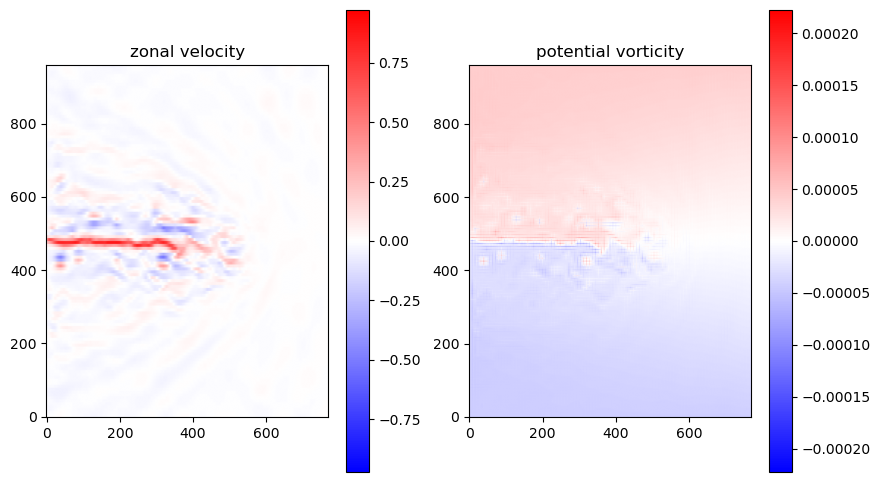

n=001000, t=0.02 yr, p: (+3.5E-02, 3.489552E-01), q: (+1.8E-11, 2.261943E-05).
n=002000, t=0.04 yr, p: (+1.4E-02, 3.515168E-01), q: (+1.2E-11, 2.260479E-05).
n=003000, t=0.06 yr, p: (-1.7E-02, 3.522196E-01), q: (-1.8E-10, 2.259790E-05).
n=004000, t=0.08 yr, p: (-2.3E-02, 3.514645E-01), q: (-3.1E-10, 2.259086E-05).
n=005000, t=0.10 yr, p: (+4.7E-03, 3.514742E-01), q: (-7.1E-10, 2.258536E-05).
n=006000, t=0.11 yr, p: (+2.7E-02, 3.568088E-01), q: (-1.3E-09, 2.258078E-05).
n=007000, t=0.13 yr, p: (+1.2E-02, 3.550845E-01), q: (-2.2E-09, 2.257711E-05).
n=008000, t=0.15 yr, p: (-1.3E-02, 3.472316E-01), q: (-3.4E-09, 2.257348E-05).
n=009000, t=0.17 yr, p: (-2.8E-02, 3.411803E-01), q: (-4.7E-09, 2.256988E-05).
n=010000, t=0.19 yr, p: (-1.7E-02, 3.379271E-01), q: (-5.5E-09, 2.256557E-05).
Total computation time: 63.330862522125244 seconds
torch.Size([5513, 3, 769, 961])


In [4]:
qg_multilayer = QGM(param)

if param['nx'] == 97:
    qg_multilayer.p = torch.from_numpy(np.load('notebooks/QG/p_380yrs_HRDS.npy')).to(param['device'])
else:
    qg_multilayer.p = torch.from_numpy(init_HR).to(param['device'])
qg_multilayer.compute_q_over_f0_from_p()


# time params
dt = param['dt']
t = 0

freq_plot = 1000000 # LR
# freq_plot = 50 # HR
freq_checknan = 10000
freq_log = 1000
n_years = 0.2
n_steps_burn = 5000
n_steps = int(n_years*365*24*3600 / dt)

if freq_plot > 0:
    import matplotlib.pyplot as plt
    plt.ion()
    f,a = plt.subplots(1,2, figsize=(10,6))
    u = (qg_multilayer.compute_u()[0]).cpu().numpy()
    um, uM = -1.1*np.abs(u).max(), 1.1*np.abs(u).max()
    im = a[0].imshow(u[0].T, cmap='bwr', origin='lower', vmin=um, vmax=uM, animated=True)
    a[0].set_title('zonal velocity')
    f.colorbar(im, ax=a[0])
    q = (qg_multilayer.q_over_f0*qg_multilayer.f0).cpu().numpy()
    qm, qM = -1.1*np.abs(q).max(), 1.1*np.abs(q).max()
    im = a[1].imshow(q[0].T, cmap='bwr', origin='lower', vmin=qm, vmax=qM, animated=True)
    a[1].set_title('potential vorticity')
    f.colorbar(im, ax=a[1])
    plt.pause(5)

times, outputs = [], []

#time_series_p = torch.zeros(n_steps+1, *qg_multilayer.p.shape).to(qg_multilayer.p.dtype)
#time_series_q_over_f0 = torch.zeros(n_steps+1, *qg_multilayer.q_over_f0.shape).to(qg_multilayer.q_over_f0.dtype)
time_series_p = torch.zeros(n_steps-n_steps_burn+1, *qg_multilayer.p.shape).to(torch.float32)
time_series_q_over_f0 = torch.zeros(n_steps-n_steps_burn+1, *qg_multilayer.q_over_f0.shape).to(torch.float32)

#time_series_p[0] = qg_multilayer.p.clone()
#time_series_q_over_f0[0] = qg_multilayer.q_over_f0.clone()
#time_series_p[0] = qg_multilayer.p.clone().to(torch.float32)
#time_series_q_over_f0[0] = qg_multilayer.q_over_f0.clone().to(torch.float32)
initial_pressure = qg_multilayer.p.clone().to(torch.float32)
initial_PV = qg_multilayer.q_over_f0.clone().to(torch.float32)

t0 = time()
for n in range(1, n_steps+1):
    qg_multilayer.step()
    t += dt

    if n >= n_steps_burn:
        time_series_p[n-n_steps_burn] = qg_multilayer.p.clone().to(torch.float32)
        time_series_q_over_f0[n-n_steps_burn] = qg_multilayer.q_over_f0.clone().to(torch.float32)

    if n % freq_checknan == 0 and torch.isnan(qg_multilayer.p).any():
        raise ValueError('Stopping, NAN number in p at iteration {n}.')

    if freq_plot > 0 and n % freq_plot == 0:
        u = (qg_multilayer.compute_u()[0]).cpu().numpy()
        a[0].imshow(u[0].T, cmap='bwr', origin='lower', vmin=um, vmax=uM, animated=True)
        q = (qg_multilayer.q_over_f0*qg_multilayer.f0).cpu().numpy()
        a[1].imshow(q[0].T, cmap='bwr', origin='lower', vmin=qm, vmax=qM, animated=True)
        plt.suptitle(f't={t/(365*24*3600):.2f} years.')
        plt.pause(0.1)

    if freq_log > 0 and n % freq_log == 0:
        q, p = (qg_multilayer.f0 * qg_multilayer.q_over_f0).cpu().numpy(), qg_multilayer.p.cpu().numpy()
        print(f'{n=:06d}, t={t/(365*24*60**2):.2f} yr, ' \
              f'p: ({p.mean():+.1E}, {np.abs(p).mean():.6E}), ' \
              f'q: ({q.mean():+.1E}, {np.abs(q).mean():.6E}).')
print(f'Total computation time: {time()-t0} seconds')

print(time_series_p.shape)

Let us now visualise the pressure field on the 3 layers and at different time steps.

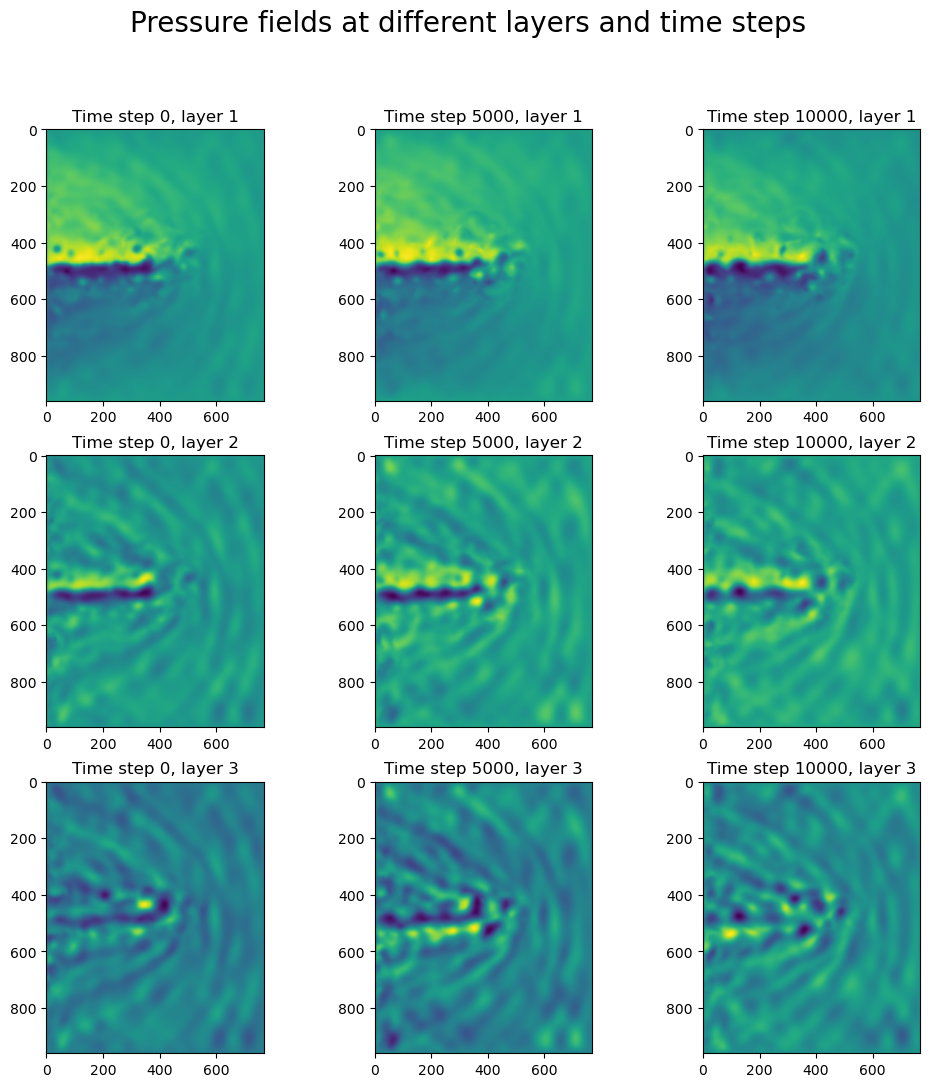

In [5]:
vmin, vmax = torch.min(time_series_p), torch.max(time_series_p)

#normalized_ts_p = (time_series_p.clone().to(torch.float16) - vmin) / (vmax - vmin)
norm_steps = 2000
normalized_ts_p = torch.zeros(time_series_p.shape, dtype=torch.float16)
for k in range(1 + time_series_p.shape[0] // norm_steps):
    normalized_ts_p[k*norm_steps:(k+1)*norm_steps] = (time_series_p[k*norm_steps:(k+1)*norm_steps].clone().to(torch.float16) - vmin) / (vmax - vmin)

times = [k*5000 for k in range(3)]
#times = [k*3000 for k in range(3)]
fig, ax = plt.subplots(3, 3, figsize=(12,12))

fig.suptitle('Pressure fields at different layers and time steps', fontsize=20)

#ax[0,0].imshow(normalized_ts_p[times[0], 0].permute((1,0)))
ax[0,0].imshow(initial_pressure[0].detach().cpu().permute((1,0)))
ax[0,0].set_title(f'Time step {times[0]}, layer 1')

#ax[0,1].imshow(normalized_ts_p[times[1], 0].permute((1,0)))
ax[0,1].imshow(normalized_ts_p[times[1] - n_steps_burn, 0].permute((1,0)))
ax[0,1].set_title(f'Time step {times[1]}, layer 1')

#ax[0,2].imshow(normalized_ts_p[times[2], 0].permute((1,0)))
ax[0,2].imshow(normalized_ts_p[times[2] - n_steps_burn, 0].permute((1,0)))
ax[0,2].set_title(f'Time step {times[2]}, layer 1')

#ax[1,0].imshow(normalized_ts_p[times[0], 1].permute((1,0)))
ax[1,0].imshow(initial_pressure[1].detach().cpu().permute((1,0)))
ax[1,0].set_title(f'Time step {times[0]}, layer 2')

#ax[1,1].imshow(normalized_ts_p[times[1], 1].permute((1,0)))
ax[1,1].imshow(normalized_ts_p[times[1] - n_steps_burn, 1].permute((1,0)))
ax[1,1].set_title(f'Time step {times[1]}, layer 2')

#ax[1,2].imshow(normalized_ts_p[times[2], 1].permute((1,0)))
ax[1,2].imshow(normalized_ts_p[times[2] - n_steps_burn, 1].permute((1,0)))
ax[1,2].set_title(f'Time step {times[2]}, layer 2')

#ax[2,0].imshow(normalized_ts_p[times[0], 2].permute((1,0)))
ax[2,0].imshow(initial_pressure[2].detach().cpu().permute((1,0)))
ax[2,0].set_title(f'Time step {times[0]}, layer 3')

#ax[2,1].imshow(normalized_ts_p[times[1], 2].permute((1,0)))
ax[2,1].imshow(normalized_ts_p[times[1] - n_steps_burn, 2].permute((1,0)))
ax[2,1].set_title(f'Time step {times[1]}, layer 3')

#ax[2,2].imshow(normalized_ts_p[times[2], 2].permute((1,0)))
ax[2,2].imshow(normalized_ts_p[times[2] - n_steps_burn, 2].permute((1,0)))
ax[2,2].set_title(f'Time step {times[2]}, layer 3')

del normalized_ts_p

# Sliding-window strong-constraint 4D-Var

Here, since the size of the system limits our ability to assimilate on a long window, we will resort to sliding-window 4D-Var in order to take more observations into account.

In [6]:
dtype = torch.float32

n_obs_steps = 3000

fields_tensordict = TensorDict(p=time_series_p.unsqueeze(0)[:,:n_obs_steps].to(dtype),  
                               batch_size=(1, n_obs_steps))
true_ts = State(fields_tensordict, time_axis=torch.arange(0, dt*n_obs_steps, dt, dtype=dtype))

noise_amplitude = 0.02  # observation noise s.d.
noise_amplitude = 0.05
#noise_amplitude = 0.1
p_obs = 0.005 # 99.5% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_ts, 
                                                            noise_amplitude, 
                                                            p_obs,
                                                            constant_obs_count=False,
                                                            constant_obs_count_per_step=False)

One can see below that the evolution of the system state is clearly visible, although moderate, over 3000 time steps.

Text(0.5, 1.0, 'Time step 2999, observations')

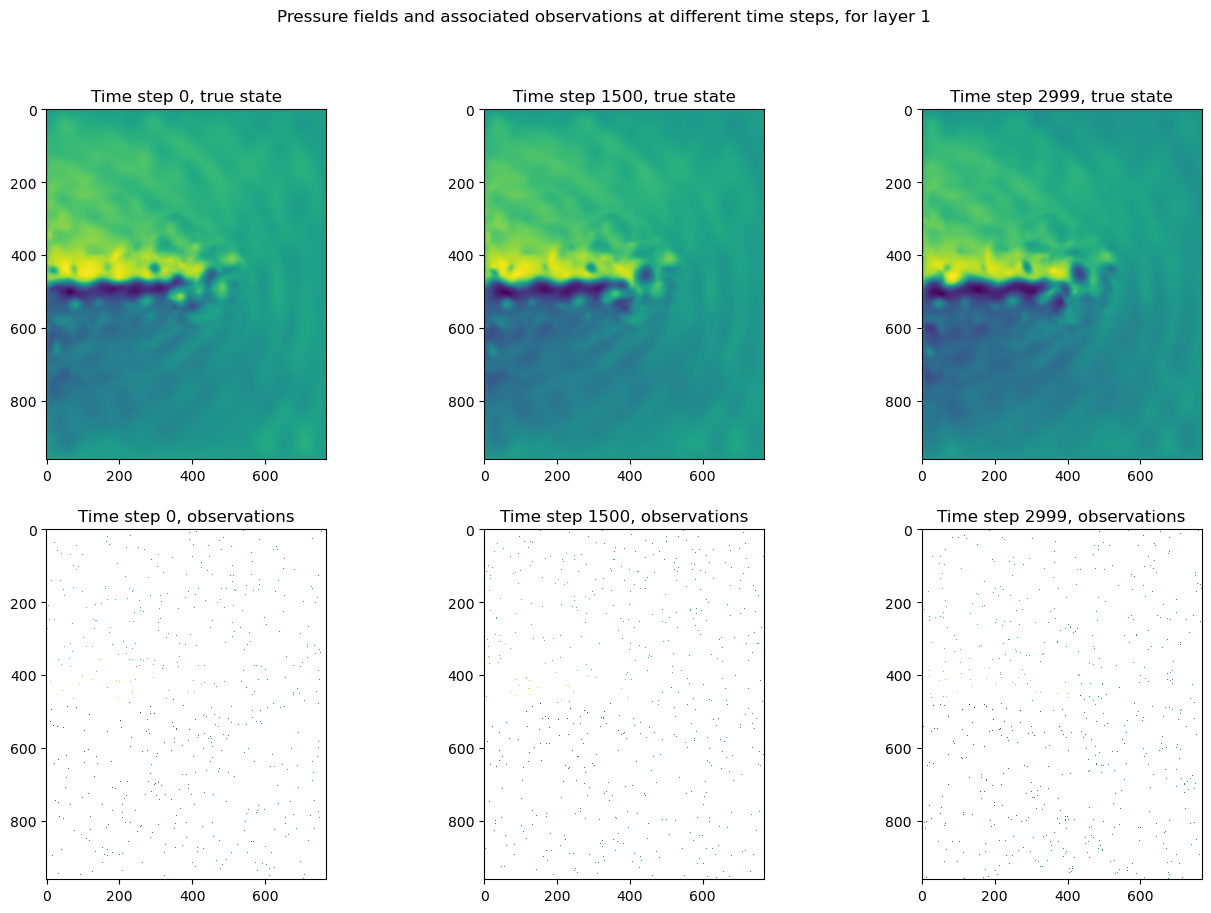

In [7]:
layer = 0 # choose the layer to show among [0, 1, 2]

times = [0, n_obs_steps // 2, n_obs_steps - 1]
fig, ax = plt.subplots(2, 3, figsize=(16,10))

fig.suptitle(f'Pressure fields and associated observations at different time steps, for layer {layer+1}')

ax[0,0].imshow(true_ts.fields['p'][0, times[0], layer].detach().cpu().permute((1,0)))
ax[0,0].set_title(f'Time step {times[0]}, true state')

ax[0,1].imshow(true_ts.fields['p'][0, times[1], layer].detach().cpu().permute((1,0)))
ax[0,1].set_title(f'Time step {times[1]}, true state')

ax[0,2].imshow(true_ts.fields['p'][0, times[2], layer].detach().cpu().permute((1,0)))
ax[0,2].set_title(f'Time step {times[2]}, true state')

ax[1,0].imshow(observations.state.fields['p'][0, times[0], layer].cpu().detach().permute((1,0)), interpolation='none')
ax[1,0].set_title(f'Time step {times[0]}, observations')

ax[1,1].imshow(observations.state.fields['p'][0, times[1], layer].cpu().detach().permute((1,0)), interpolation='none')
ax[1,1].set_title(f'Time step {times[1]}, observations')

ax[1,2].imshow(observations.state.fields['p'][0, times[2], layer].cpu().detach().permute((1,0)), interpolation='none')
ax[1,2].set_title(f'Time step {times[2]}, observations')

In [8]:
Cl2m = qg_multilayer.Cl2m
Cm2l = qg_multilayer.Cm2l
jac_coef, jacobi_h = qg_multilayer.jac_coef, qg_multilayer.jacobi_h
p_prime = qg_multilayer.p_prime
laplacian_h = qg_multilayer.laplacian_h
zfbc = qg_multilayer.zfbc

def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    """ Time itegration with Heun (RK2) scheme.
    Input x is a state containing 2 fields: p and q/f0"""
    B, T = x.fields.batch_size[:2]
    assert (B, T) == (1, 1), "Input state x is expected to have no batch or time dimensions"
    p = x.fields["p"].flatten(0, 2) # remove batch and time dimensions
    qg_multilayer.p = p
    qg_multilayer.compute_q_over_f0_from_p() # Use the state p to compute q/f0 before integration
    qg_multilayer.compute_time_derivatives()
    dq_over_f0_0, dp_0 = qg_multilayer.dq_over_f0, qg_multilayer.dp
    q_over_f0_intermed = qg_multilayer.q_over_f0 + dt * dq_over_f0_0
    p_intermed = qg_multilayer.p + dt * dp_0
    qg_multilayer.p, qg_multilayer.q_over_f0 = p_intermed, q_over_f0_intermed

    qg_multilayer.compute_time_derivatives(update_PV=False)
    p_next = p_intermed + dt * 0.5 * (qg_multilayer.dp - dp_0)
    # No need to compute q_over_f0_next here

    new_fields = TensorDict(p=p_next.reshape(1, 1, *p_next.shape),
                            batch_size=(B, T))
    return State(new_fields, time_axis=x.time_axis + dt) # return State object, advancing time

In [9]:
t0 = time()
initialization = fast_initialization_strong_constraint(observations, default_value=0) # naive initialization on the firt time step of the time series


initialization.fields = initialization.fields.to(device)

# We take care of the variables that have no observations in the window by attributing them the average value of neighboring variables
_, _, ind1, ind2, ind3 = torch.where(initialization.fields['p'] == 0)
for k in range(len(ind1)):
    bounds2 = (max(ind2[k]-1, 0), min(ind2[k]+1, initialization.fields['p'].shape[3]))
    bounds3 = (max(ind3[k]-1, 0), min(ind3[k]+1, initialization.fields['p'].shape[4]))
    initialization.fields['p'][0, 0, ind1[k], ind2[k], ind3[k]] = torch.mean(initialization.fields['p'][0, 0, ind1[k], bounds2[0]:bounds2[1], bounds3[0]:bounds3[1]])
print(f"Time for the initialization: {time()-t0}")

Time for the initialization: 2.832432508468628


[tensor(1.0162), tensor(0.2516), tensor(0.2003)]


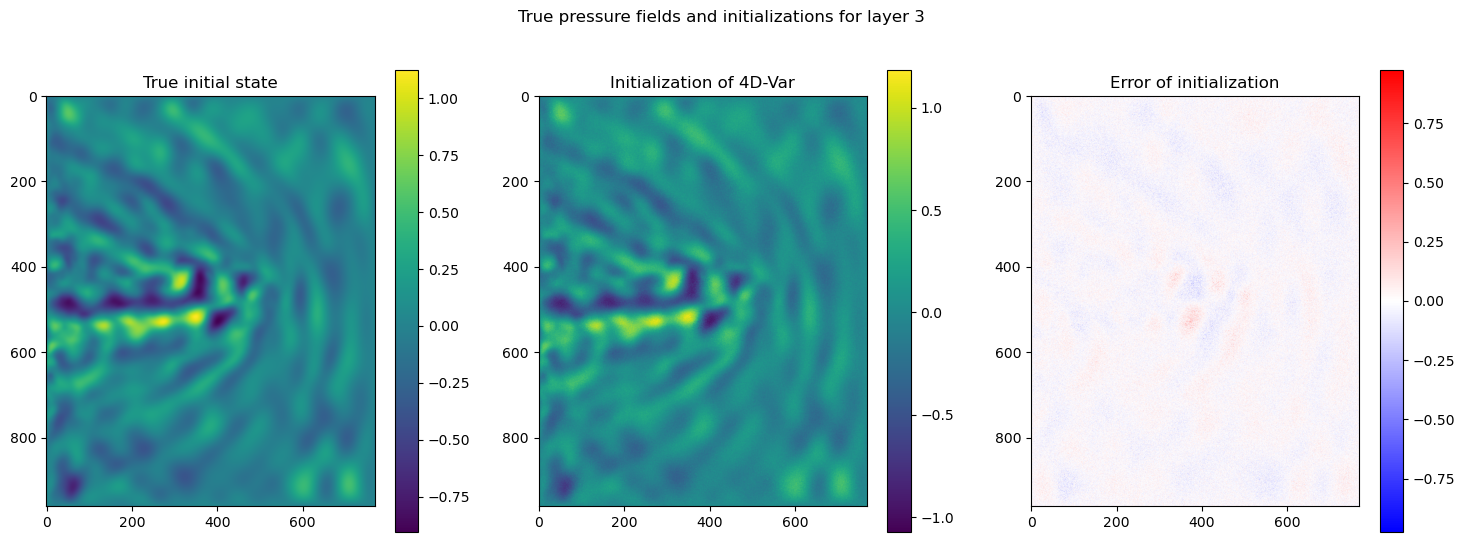

In [10]:
layer = 0
layer = 1
layer = 2 # choose the layer to show among [0, 1, 2]
title_fontsize = 12

fig, ax = plt.subplots(1, 3, figsize=(18,6))

fig.suptitle(f'True pressure fields and initializations for layer {layer+1}')

img_0 = ax[0].imshow(true_ts.fields['p'][0, 0, layer].detach().cpu().permute((1,0)))
plt.colorbar(img_0, ax=ax[0])
ax[0].set_title(f'True initial state', fontsize=title_fontsize)

img_1 = ax[1].imshow(initialization.fields['p'][0, 0, layer].detach().cpu().permute((1,0)))
plt.colorbar(img_1, ax=ax[1])
ax[1].set_title(f'Initialization of 4D-Var', fontsize=title_fontsize)

true_init_gpu = true_ts[:,0:1]
true_init_gpu.fields = true_init_gpu.fields.to(device)

vmax_abs = torch.max((true_init_gpu - initialization.detach()).fields['p'][0,0, layer].abs())
img_2 = ax[2].imshow((true_init_gpu - initialization).fields['p'][0, 0, layer].detach().cpu().permute((1,0)),
                       vmin=-vmax_abs, vmax=vmax_abs, cmap='bwr')
plt.colorbar(img_2, ax=ax[2])
ax[2].set_title(f'Error of initialization', fontsize=title_fontsize)

print([torch.std(true_ts.fields['p'][:,:,layer]) for layer in [0, 1, 2]])

In [11]:
# Make sure that all time stepping operations are gonna be performed in 32-bit precision
qg_multilayer.A = qg_multilayer.A.to(dtype)
qg_multilayer.homogeneous_sol = qg_multilayer.homogeneous_sol.to(dtype)
qg_multilayer.alpha_matrix = qg_multilayer.alpha_matrix.to(dtype)
qg_multilayer.Cl2m = qg_multilayer.Cl2m.to(dtype)
qg_multilayer.Cm2l = qg_multilayer.Cm2l.to(dtype)
qg_multilayer.wind_forcing = qg_multilayer.wind_forcing.to(dtype)
qg_multilayer.zfbc = qg_multilayer.zfbc.to(dtype)

In [12]:
background_prior = DiagonalGaussian(initialization.fields.to(device), 
                                    TensorDict(p=torch.ones(1, 1, *initialization.fields['p'].shape[2:]).to(device) * noise_amplitude * 1.5, batch_size=(1,1)))
covariance_factors = 0.25 # sigma is 1.5*noise_std for the first window, then 0.375*noise_std

In [13]:
t0 = time()
assimilated_ic = sc4dvar_sliding_window(next_step_function, 
                                        observations, 
                                        obs_op, 
                                        window_duration=500*param['dt'],
                                        window_shift=1.0,
                                        x_init=initialization,
                                        background_prior=background_prior,
                                        covariance_factors=covariance_factors,
                                        optimizer_class=torch.optim.Adam,
                                        optimizer_pars={'lr': 2e-3},
                                        scheduler_class=torch.optim.lr_scheduler.CyclicLR,
                                        scheduler_pars={'base_lr': 2e-3, 'max_lr': 5e-3, 'step_size_up': 10},
                                        n_steps=40,
                                        verbose=1
                                        )                                     
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

/home/g/g260252/da-tools-QG/da-tools/da-tools-65/adda/variational/base.py:44: UserWarning: using float32 for state time axis can lead to precision issues when checking for fixed dt in long sequences. HINT: try generating and providing time tensor using double precision if shape mismatch assertion presents.
  warnings.warn(


Time steps 0 to 500
iteration 0: loss = 7202738.5
iteration 0: lr = 0.0023000000000000004
iteration 1: loss = 6977658.0
iteration 1: lr = 0.0026000000000000007
iteration 2: loss = 6775142.0
iteration 2: lr = 0.0028999999999999994
iteration 3: loss = 6593772.0
iteration 3: lr = 0.0031999999999999997
iteration 4: loss = 6434722.5
iteration 4: lr = 0.0035
iteration 5: loss = 6296627.0
iteration 5: lr = 0.0038000000000000004
iteration 6: loss = 6180204.0
iteration 6: lr = 0.004100000000000001
iteration 7: loss = 6082823.5
iteration 7: lr = 0.004399999999999999
iteration 8: loss = 6000026.0
iteration 8: lr = 0.004699999999999999
iteration 9: loss = 5929801.5
iteration 9: lr = 0.005
iteration 10: loss = 5869886.5
iteration 10: lr = 0.004699999999999999
iteration 11: loss = 5817403.5
iteration 11: lr = 0.004399999999999999
iteration 12: loss = 5774962.0
iteration 12: lr = 0.004100000000000001
iteration 13: loss = 5740348.5
iteration 13: lr = 0.0038000000000000004
iteration 14: loss = 5711705.

Let us now see how well we can approximate the true state thanks to our assimilated states.

In [14]:
from adda.util.state_space import rollout

n_steps_per_window = 500 # This might cause a GPU memory issue. If this happens, try a lower number or run the prediction on CPU

with torch.no_grad():
    predictions_list = []
    for k in range(len(true_ts.time_axis) // n_steps_per_window):
        prediction_partial = rollout(next_step_function, 
                                     true_ts.time_axis[k*n_steps_per_window : (k+1)*n_steps_per_window], 
                                     assimilated_ic[0][k])
        prediction_partial.fields = prediction_partial.fields.to('cpu')
        prediction_partial.fields = prediction_partial.fields.to(torch.float16)
        predictions_list.append(prediction_partial.clone())
    predictions_td = TensorDict(p=torch.cat([prediction.fields['p'] for prediction in predictions_list], axis=1))
    print(predictions_td)
    predictions = State(predictions_td, true_ts.time_axis)

TensorDict(
    fields={
        p: Tensor(shape=torch.Size([1, 3000, 3, 769, 961]), device=cpu, dtype=torch.float16, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)


RMSE=0.00896765198558569


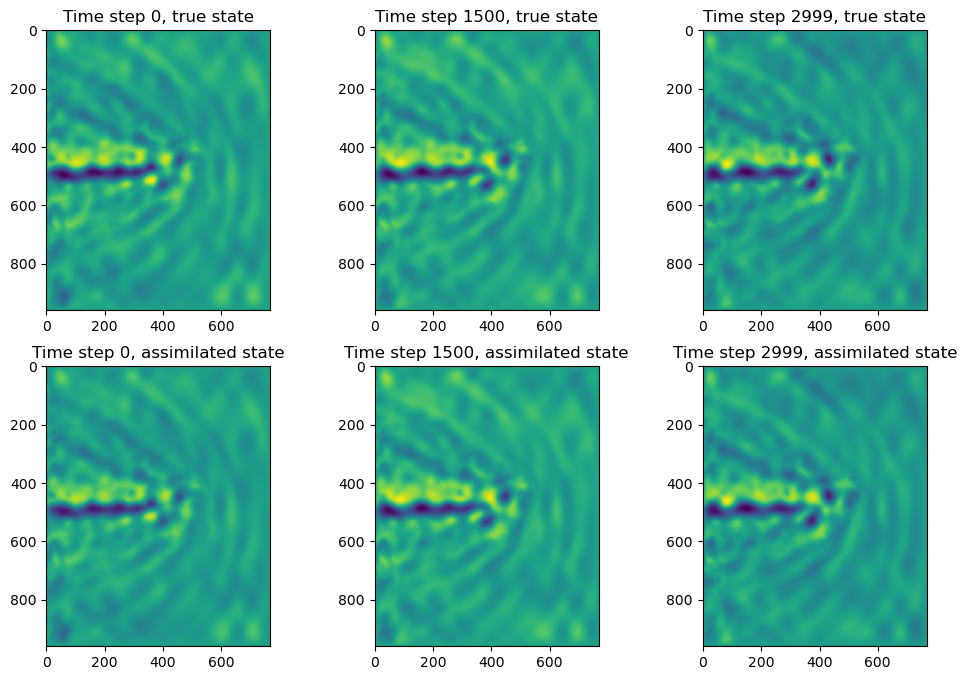

In [15]:
field = 'p'
var = 1 # choose the variable to show among [0, 1, 2]

times = [0, 1500, 2999]
fig, ax = plt.subplots(2, 3, figsize=(12,8))

#fig.suptitle(f'Pressure fields, layer {var+1}')

ax[0,0].imshow(true_ts.fields['p'][0, times[0], var].detach().cpu().permute((1,0)))
ax[0,0].set_title(f'Time step {times[0]}, true state')

ax[0,1].imshow(true_ts.fields['p'][0, times[1], var].detach().cpu().permute((1,0)))
ax[0,1].set_title(f'Time step {times[1]}, true state')

ax[0,2].imshow(true_ts.fields['p'][0, times[2], var].detach().cpu().permute((1,0)))
ax[0,2].set_title(f'Time step {times[2]}, true state')

ax[1,0].imshow(predictions.fields['p'][0, times[0], var].detach().cpu().permute((1,0)))
ax[1,0].set_title(f'Time step {times[0]}, assimilated state')

ax[1,1].imshow(predictions.fields['p'][0, times[1], var].detach().cpu().permute((1,0)))
ax[1,1].set_title(f'Time step {times[1]}, assimilated state')

ax[1,2].imshow(predictions.fields['p'][0, times[2], var].detach().cpu().permute((1,0)))
ax[1,2].set_title(f'Time step {times[2]}, assimilated state')

RMSE = torch.sqrt(torch.mean((predictions.fields['p'] - true_ts.fields['p']) **2)).item()
print(f'RMSE={RMSE}')

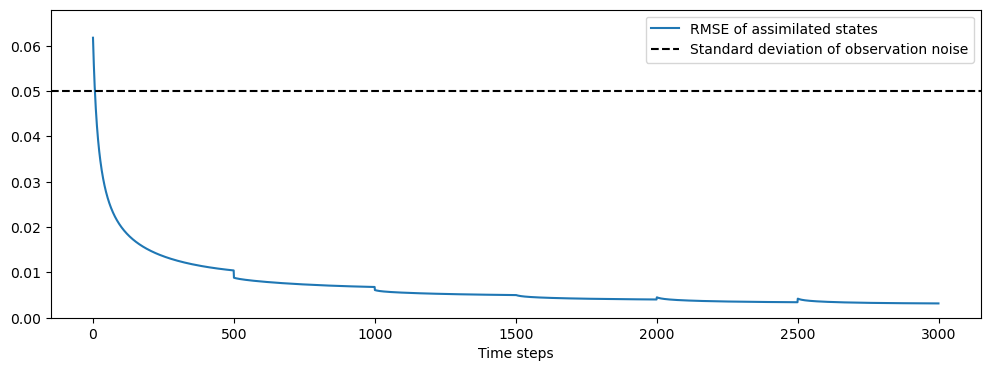

In [16]:
RMSE_in_time = torch.sqrt(torch.mean((predictions - true_ts).fields['p'] **2, axis=(0, 2, 3, 4)))

fig, ax = plt.subplots(figsize=(12,4))
ax.set_ylim(0, 1.1 * torch.max(RMSE_in_time))

plt.plot(RMSE_in_time.detach().cpu(), label='RMSE of assimilated states')

plt.axhline(noise_amplitude, c='black', linestyle='--', label='Standard deviation of observation noise')
#plt.axvline(n_obs_steps, c='pink', linestyle='--', label='Limit of assimilation window')
            
plt.xlabel('Time steps')


plt.legend()

The discontinuities in the RMSE correspond to the transitions between observation windows, every 500 time steps. One can clealy see that, as more observations are assimilated, the quality of the reconstruction improves.

Finally, we will now generate an animation to compare the fields obtained when rolling out the assimilated state at the very end of the observed interval, with regards to the true time series. The resulting GIF file 'compare.gif' can be found in the 'QG' folder.

In [17]:
forecasting_steps = 40000
save_every = 100

predictions_long = []
current_state = predictions[:,n_obs_steps-1:n_obs_steps].to(device).to(dtype)
for t in range (0, forecasting_steps):
    if t % save_every == 0:
        predictions_long.append(current_state.to('cpu'))
    current_state = next_step_function(current_state, param['dt'], None, None)
    
time_series_pred = torch.cat([pred.fields['p'] for pred in predictions_long]).squeeze()

In [18]:
gt_long = []
current_state = true_ts[:,n_obs_steps-1:n_obs_steps].to(device).to(dtype)
for t in range (0, forecasting_steps):
    if t % save_every == 0:
        gt_long.append(current_state.to('cpu'))
    current_state = next_step_function(current_state, param['dt'], None, None)
    
time_series_gt = torch.cat([gt.fields['p'] for gt in gt_long]).squeeze()

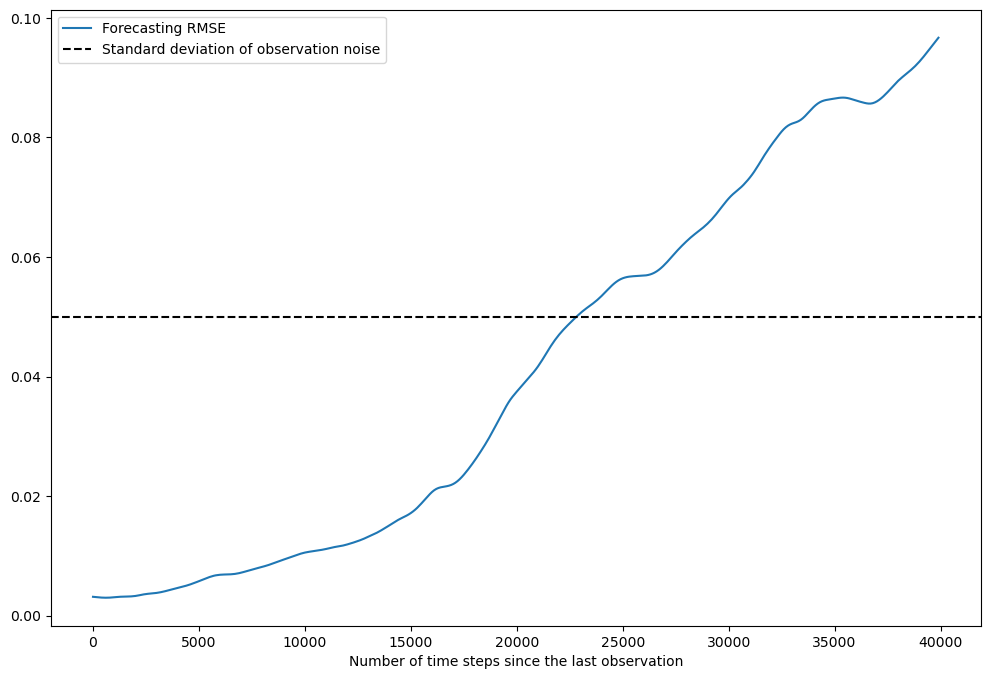

In [19]:
RMSE_over_time = torch.sqrt(torch.mean((time_series_pred - time_series_gt) **2, axis=(1,2,3)))

fig, ax = plt.subplots(figsize=(12,8))

plt.plot([save_every*t for t in range(len(RMSE_over_time))], RMSE_over_time, label='Forecasting RMSE')
plt.axhline(noise_amplitude, c='black', linestyle='--', label='Standard deviation of observation noise')
plt.xlabel('Number of time steps since the last observation')
plt.legend()
plt.show()

One can see that the forecasting RMSE slowly but steadily increases with time.

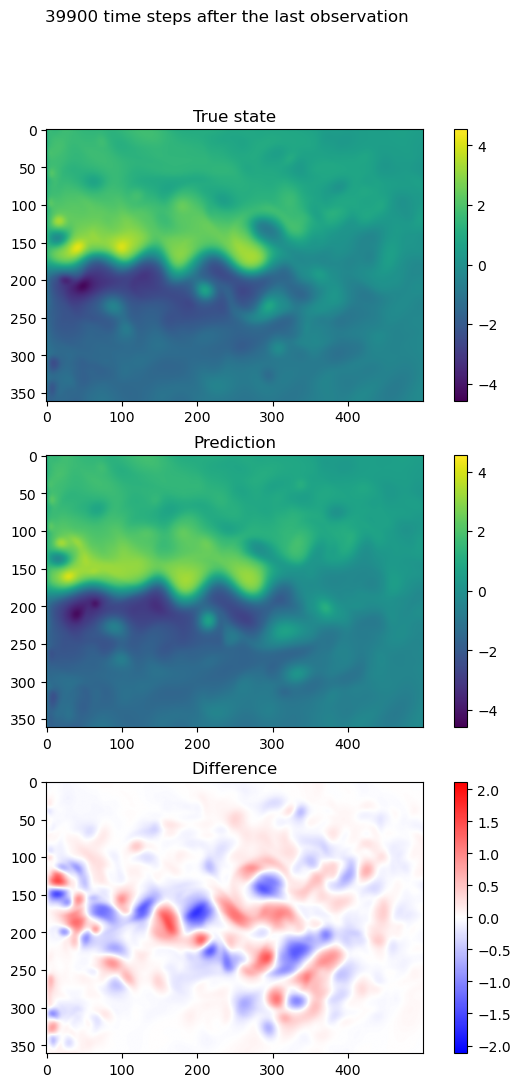

In [20]:
fig, ax = plt.subplots(3, figsize=(8, 12))

bound_x = 500
bound_y = (300, param['ny'] - 300)

layer = 0 # choose the layer to show among [0, 1, 2]
sequence_pred = [time_series_pred[t,layer].transpose(1,0).numpy() for t in range(time_series_pred.shape[0])]
sequence_gt = [time_series_gt[t,layer].transpose(1,0).numpy() for t in range(time_series_gt.shape[0])]
max_absdiff = np.max(np.abs(np.array(sequence_gt) - np.array(sequence_pred))[:, bound_y[0]:bound_y[1], :bound_x])

vmin, vmax = np.min(np.array(sequence_gt)), np.max(np.array(sequence_gt))

t=0
im0 = ax[0].imshow(sequence_gt[t][bound_y[0]:bound_y[1], :bound_x],
                  vmin=vmin, vmax=vmax)
cb0 = plt.colorbar(im0, ax=ax[0])#, vmin=vmin, vmax=vmax)
im1 = ax[1].imshow(sequence_pred[t][bound_y[0]:bound_y[1], :bound_x],
                  vmin=vmin, vmax=vmax)
cb1 = plt.colorbar(im1, ax=ax[1])#, vmin=vmin, vmax=vmax)
im2 = ax[2].imshow((sequence_gt[t][bound_y[0]:bound_y[1], :bound_x] - 
                    sequence_pred[t][bound_y[0]:bound_y[1], :bound_x]),
                   vmin=-max_absdiff, vmax=max_absdiff, cmap='bwr')
cb2 = plt.colorbar(im2, ax=ax[2])
ax[0].set_title('True state')
ax[1].set_title('Prediction')
ax[2].set_title('Difference')

def animate(t):
    im0.set_data(sequence_gt[t][bound_y[0]:bound_y[1], :bound_x])
    im1.set_data(sequence_pred[t][bound_y[0]:bound_y[1], :bound_x])
    diff = (
        sequence_gt[t][bound_y[0]:bound_y[1], :bound_x]
        - sequence_pred[t][bound_y[0]:bound_y[1], :bound_x]
    )
    im2.set_data(diff)
    fig.suptitle(f'{t*save_every} time steps after the last observation')

ani = animation.FuncAnimation(
    fig,
    animate,
    interval=50,
    blit=False,
    frames = [t for t in range(forecasting_steps // save_every)],
    repeat_delay=100,
)

# This should take a few minutes
ani.save('QG/compare.gif')

plt.show()

Due to its large size, the file 'compare.gif' is not available on our Github repository. However, one can obtain it by either running this notebook locally or downloading it from Zenodo (https://zenodo.org/records/22127623), in notebooks/QG. The GIF file shows a long-time consistency between the assimilated and true states.